# PatchTST RevIN price forecasting -- step 3 (raw OHLC + volume)

**Step 3 of the experiment ladder: raw OHLC price target (RevIN), volume back in.** Steps
1-2 used the anchored log-return decomposition (`open_ret`/`body_ret`/wicks); step 2 showed
that decomposition collapses to a directionless "predict ~0" shortcut once volume (the only
loss term with real gradient variance) is removed. A RevIN-based raw-price target was
already tried once before on this branch and fixed that exact collapse (0/2397 -> 95-98%
coherence) -- but that earlier run also dropped volume entirely, so it never actually
isolated whether the fix was about the *target* (return -> absolute price) or was
entangled with volume being gone too. This run adds volume back in to close that gap.

**Target**: raw OHLC price, normalized per-window with a real **RevIN** (Reversible
Instance Normalization, Kim et al. 2021 -- learnable per-channel `affine_weight`/
`affine_bias`, not HF `PatchTSTModel`'s built-in scaler, which has neither).

**Volume gets a different normalization than OHLC, deliberately.** RevIN's premise (recent
local window predicts near-term future) fits price's gradual multi-year drift well, but
volume is bursty within a window (earnings days, opex, macro news) in a way price isn't --
a single spike bar inside a 70-bar window would blow up that window's local std and squash
every *other* bar's normalized volume toward ~0, making the target noisy and window-
dependent rather than stable. So **volume reuses `data_pipeline.py`'s existing global
`log_volume_norm`** (log1p + one fixed train-set mean/std, the same normalization every
other notebook in this project already uses for volume) instead of going through RevIN.
`log_volume_norm` is already ~unit-variance by construction, so it's on a comparable scale
to RevIN-normalized OHLC (~unit-variance per window) -- this doesn't reintroduce step 1's
loss-imbalance problem, it just gives volume a *stable* (global) scale instead of a *local*
(per-window, small-sample) one.

**Kept identical to the rest of this notebook family, for comparability**:
- Data: `steven/data/spy_ohlcv_1h.parquet`, same chronological train/val/test splits.
- `patch_length=7`, `patch_stride=7`, fixed `context_length=MAX_CONTEXT=70`, `HORIZON=3`.
- Model capacity (`d_model=64`, 4 heads, 3 layers) and training hyperparameters
  (`lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x 20,000 windows/epoch).
- `channel_attention` swept True/False in one pass, same as steps 1-2.

**What's different from steps 1-2**:
- Context and target are raw OHLC (RevIN-normalized) + `log_volume_norm` (globally
  normalized) -- no `open_ret`/`body_ret`/wick decomposition, no `close_0` anchoring, no
  calendar/timing channels.
- **No `tanh`/`sigmoid` output bounding on price.** That bounding existed specifically
  because log-returns have a natural physical cap (`MAX_LOG_RETURN`); RevIN-normalized
  price doesn't have the same interpretation, so the price head is a plain linear
  projection here (volume's output is likewise unbounded, same as its treatment in steps 1-2).
- Volume reconstruction reuses `data_pipeline.py`'s own `reconstruct_volume` (same function
  every other notebook in this project uses) -- no hand-rolled inverse needed, since
  `log_volume_norm` round-trips through the exact stats `build_dataset` already computed.

**Also reports the coherence-rate diagnostic** from the original RevIN run (fraction of test
windows where all 3 predicted horizon bars agree on direction) -- the cheapest signal of
whether this framing is avoiding the step-2 collapse, before a real backtest is worth
running.

**Deferred, same as every other notebook in this family**: the long-only bracket-order
backtest, until a target/volume variant is picked from the forecasting-metrics ladder.


## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv


name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB


In [2]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "patchtst_ohlcv_mse"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    #
    # fetch + checkout {BRANCH} (not just `pull`): REPO_DIR persists across notebook runs
    # within the same Colab VM session, so if an earlier run in this session cloned a
    # DIFFERENT branch (e.g. this VM was previously used for a notebook with an older
    # BRANCH value), a bare `pull` here would just pull more commits onto that stale
    # branch instead of switching -- and the push cell at the bottom would then fail with
    # "src refspec {BRANCH} does not match any", since no local branch by that name would
    # exist to push. Explicitly checking out BRANCH every time this cell runs avoids that.
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} checkout {BRANCH}
    !git -C {REPO_DIR} pull origin {BRANCH}

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}


remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 9.47 KiB | 3.16 MiB/s, done.
From https://github.com/WoodyChang21/ECE1508_GenAI
   c643f45..20a659d  patchtst_ohlcv_mse -> origin/patchtst_ohlcv_mse
Already on 'patchtst_ohlcv_mse'
Your branch is behind 'origin/patchtst_ohlcv_mse' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
From https://github.com/WoodyChang21/ECE1508_GenAI
 * branch            patchtst_ohlcv_mse -> FETCH_HEAD
Updating 3b8dc6a..20a659d
Fast-forward
 steven/experiments.md                            |  36 ++
 steven/train_patchtst_hf_channel_attention.ipynb | 736 +++++++++--------------
 2 files changed, 330 insertions(+), 442 deletions(-)
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml


In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

`EXPERIMENT` describes *this run* -- it's what gets echoed into each output JSON's
`"experiment"` block and is the thing to paste into `docs/experiments.md`'s row when logging
the result, so the doc and the actual run config can't drift apart. Update `name`/`description`
each time this notebook is repurposed for a different target/volume/loss variant (per the
experiment ladder: fused-head parity check -> drop volume -> raw-price+volume ->
raw-price-no-volume -> head comparison).


In [5]:
import sys, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import build_dataset, WindowSampler, MAX_CONTEXT, HORIZON, reconstruct_volume
# No import of weighted_mse_loss/unpack_y -- this notebook's loss is plain MSE in a mixed
# RevIN(price)/global(volume) normalized space, not the anchored-return weighted loss.

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'
OHLC_COLS = ['open', 'high', 'low', 'close']
N_PRICE_CHANNELS = len(OHLC_COLS)     # 4 -- RevIN-normalized
N_CHANNELS = N_PRICE_CHANNELS + 1     # 5 -- + log_volume_norm (globally normalized, see intro markdown)
CLOSE_IDX = OHLC_COLS.index('close')  # position of close within the price sub-block

# -- Describes this run -- echoed into every output JSON and comparison_metrics/ filename.
# "name" -> comparison_metrics/{name}-channel_attention_{false,true}.json
EXPERIMENT = {
    "name": "hf_patchtst_revin_ohlc_global_volume",
    "description": (
        "HF PatchTSTModel + RevIN (OHLC only) + global log_volume_norm (volume), "
        "channel_attention swept. Step 3 of the experiment ladder -- isolates whether "
        "RevIN's earlier fix for the return-target collapse holds with volume back in, "
        "using a stable global scale for volume instead of RevIN's per-window one."
    ),
    "target": "raw_price_revin_ohlc_global_volume",
    "include_volume": True,
    "loss_weights": {"note": "unweighted -- RevIN(OHLC) and global log_volume_norm are both ~unit-variance, see intro markdown"},
}

# -- Both settings are trained in one pass -- see the training loop below.
CHANNEL_ATTENTION_SETTINGS = [False, True]

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block, same
# as every other notebook in this family, for comparable model capacity.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- one trading day, non-overlapping.
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- same as every other notebook in this family.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control -- reset again per setting in the training loop below, so both
# channel_attention runs get identical weight init, not just identical data order.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'EXPERIMENT = {EXPERIMENT}')
print(f'SEED = {SEED}, CHANNEL_ATTENTION_SETTINGS = {CHANNEL_ATTENTION_SETTINGS}')


Device: cuda
EXPERIMENT = {'name': 'hf_patchtst_revin_ohlc_global_volume', 'description': "HF PatchTSTModel + RevIN (OHLC only) + global log_volume_norm (volume), channel_attention swept. Step 3 of the experiment ladder -- isolates whether RevIN's earlier fix for the return-target collapse holds with volume back in, using a stable global scale for volume instead of RevIN's per-window one.", 'target': 'raw_price_revin_ohlc_global_volume', 'include_volume': True, 'loss_weights': {'note': 'unweighted -- RevIN(OHLC) and global log_volume_norm are both ~unit-variance, see intro markdown'}}
SEED = 0, CHANNEL_ATTENTION_SETTINGS = [False, True]


## RevIN + model

**`RevIN`**: a real implementation (mean/std + learnable `affine_weight`/`affine_bias`),
not HF `PatchTSTModel`'s built-in scaler (verified against the transformers source:
`PatchTSTStdScaler` is mean/std only, no affine correction). `fit()` computes per-window,
per-channel mean/std from the **context**'s OHLC only (`N_PRICE_CHANNELS=4`) -- volume is
deliberately excluded from RevIN, see intro markdown -- and the same stored stats are
reused to normalize the true future OHLC (for the loss) and denormalize the model's OHLC
predictions (for evaluation).

**`PatchTSTOHLCVRevIN`**: `PatchTSTModel` backbone (`scaling=None` -- RevIN is applied
externally, and only to the price channels) + the same fused/flattened head design used
throughout this project. The model's input/output is still `N_CHANNELS=5` (RevIN handles
channels 0-3, `log_volume_norm` passes through channel 4 unchanged on the way in, and the
head predicts a 5th output value directly in `log_volume_norm` space) -- **no `tanh`/
`sigmoid` bounding** anywhere (RevIN-normalized values and `log_volume_norm` don't have the
physical cap log-returns do).


In [6]:
class RevIN(nn.Module):
    """Reversible Instance Normalization (Kim et al. 2021). fit() must be called once
    per batch with the raw context window before normalize()/denormalize() -- both use
    whatever mean/std/affine params were last fit, so they only make sense in that order
    within a single forward pass."""
    def __init__(self, num_channels: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(num_channels))
        self.affine_bias = nn.Parameter(torch.zeros(num_channels))
        self.mean = None
        self.std = None

    def fit(self, context: torch.Tensor):
        """context: (bs, T, C). Stores per-window, per-channel mean/std (detached --
        these are window statistics, not something to backprop through)."""
        self.mean = context.mean(dim=1, keepdim=True).detach()
        self.std = (context.var(dim=1, keepdim=True, unbiased=False) + self.eps).sqrt().detach()

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.mean) / self.std
        return x * self.affine_weight + self.affine_bias

    def denormalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.affine_bias) / (self.affine_weight + self.eps ** 2)
        return x * self.std + self.mean


class PatchTSTOHLCVRevIN(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.revin = RevIN(num_channels=N_PRICE_CHANNELS)   # OHLC only -- see markdown above
        self.backbone = PatchTSTModel(config)
        self.head = nn.Linear(N_CHANNELS * config.d_model, N_CHANNELS * HORIZON)
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values_raw: torch.Tensor) -> torch.Tensor:
        """past_values_raw: (bs, MAX_CONTEXT, 5) -- cols [0:4] raw OHLC, col [4]
        log_volume_norm (already globally normalized -- passed through unchanged, not
        touched by RevIN). Returns predictions in the same mixed space: cols [0:4]
        RevIN-normalized OHLC, col [4] log_volume_norm. Caller denormalizes OHLC via
        self.revin.denormalize() and volume via data_pipeline.reconstruct_volume()."""
        price_raw = past_values_raw[:, :, :N_PRICE_CHANNELS]
        vol_norm_in = past_values_raw[:, :, N_PRICE_CHANNELS:]   # already normalized, pass through

        self.revin.fit(price_raw)
        price_norm = self.revin.normalize(price_raw)
        past_values_norm = torch.cat([price_norm, vol_norm_in], dim=-1)   # (bs, MAX_CONTEXT, 5)

        base_out = self.backbone(past_values=past_values_norm)
        pooled = base_out.last_hidden_state.mean(dim=2)             # mean-pool across patches: (bs, 5, d_model)
        pooled = self.dropout(pooled)
        raw = self.head(pooled.reshape(pooled.shape[0], -1))         # (bs, N_CHANNELS*HORIZON)

        pred_norm = raw.reshape(-1, HORIZON, N_CHANNELS)
        return pred_norm


def build_model(channel_attention: bool) -> PatchTSTOHLCVRevIN:
    config = PatchTSTConfig(
        num_input_channels=N_CHANNELS,   # 5 (4 RevIN-normalized OHLC + log_volume_norm)
        context_length=MAX_CONTEXT,      # 70 (fixed, matches every other notebook in this family)
        prediction_length=HORIZON,       # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        # transformers no longer has a single unified "dropout" field on PatchTSTConfig
        # (split into these four sub-layer dropouts, see modeling_patchtst.py) -- broadcasting
        # the same rate to all four keeps this equivalent to a single nn.Dropout(p=dropout).
        attention_dropout=DROPOUT,
        positional_dropout=DROPOUT,
        path_dropout=DROPOUT,
        ff_dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=channel_attention,
        scaling=None,   # RevIN is applied externally instead -- see markdown above
    )
    return PatchTSTOHLCVRevIN(config)


## Data

Reuses `build_dataset`/`WindowSampler` from `steven/src/data_pipeline.py` for the
chronological train/val/test split boundaries, valid-start-index logic, and
`log_volume_norm` (already computed by `build_dataset`'s `apply_normalize` step using
train-only stats). Context/target windows are built directly from raw OHLC price +
`log_volume_norm` -- no `build_window()`/return-decomposition, no reconstruction needed for
OHLC at eval time (the model's denormalized output is already real price), and volume
reconstructs via the same `reconstruct_volume()` every other notebook in this project uses.

Built **once** here, shared across both `channel_attention` settings in the training loop
below, same as every other notebook in this family.


In [7]:
df, bounds, stats = build_dataset(DATA_PATH)
# raw: (N, 5) -- cols [0:4] raw OHLC price (unnormalized), col [4] log_volume_norm
# (already globally normalized by build_dataset's apply_normalize -- see markdown above).
raw = np.concatenate([
    df[OHLC_COLS].to_numpy(dtype=np.float32),
    df[['log_volume_norm']].to_numpy(dtype=np.float32),
], axis=1)

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextRawDataset(Dataset):
    """Every window uses the full MAX_CONTEXT (70 bars); target is the next HORIZON (3)
    bars, both as raw OHLC + log_volume_norm -- no padding handling needed since
    ctx_bars == MAX_CONTEXT exactly (same fixed-context simplification as every other
    notebook in this family)."""
    def __init__(self, raw: np.ndarray, start_indices: np.ndarray):
        self.raw = raw
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        s = int(self.start_indices[i])
        context = self.raw[s : s + MAX_CONTEXT]
        target  = self.raw[s + MAX_CONTEXT : s + MAX_CONTEXT + HORIZON]
        return {
            'past_values': torch.from_numpy(context),
            'future_values': torch.from_numpy(target),
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'future_values': torch.stack([b['future_values'] for b in batch]),
    }


train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
test_starts_full   = test_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')
print(f'Valid test starts (ctx=70) : {len(test_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextRawDataset(raw, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextRawDataset(raw, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)


Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469
Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
Valid test starts (ctx=70) : 2,397


## Training + evaluation

Trains one model per entry in `CHANNEL_ATTENTION_SETTINGS`, evaluates each on the same
fixed test set, and writes one JSON per setting to `steven/comparison_metrics/`.

**Loss**: plain MSE between predicted and true values in the mixed normalized space --
OHLC normalized via RevIN (context-derived stats), volume already in `log_volume_norm`
space (no further transform needed, see intro markdown).

**Evaluation** reports OHLC MAE/RMSE (RevIN-denormalized) and volume MAE/RMSE
(`reconstruct_volume`-denormalized, real share units), per-horizon-bar directional
accuracy, and the **coherence rate** (fraction of test windows where all 3 predicted
horizon bars agree on direction) -- the cheapest diagnostic for whether this framing avoids
step 2's collapse; that run scored 0/2397 on this exact check.

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers in `steven/outputs/metrics.json`, not his "overall" (mixed-length) numbers.



training channel_attention_false
epoch  1/20  train_loss=0.899285  val_loss=1.280429
epoch  2/20  train_loss=0.360799  val_loss=0.259509
epoch  3/20  train_loss=0.327732  val_loss=0.338139
epoch  4/20  train_loss=0.318702  val_loss=0.232698
epoch  5/20  train_loss=0.301098  val_loss=0.255174
epoch  6/20  train_loss=0.287728  val_loss=0.284386
epoch  7/20  train_loss=0.280553  val_loss=0.205746
epoch  8/20  train_loss=0.272507  val_loss=0.206775
epoch  9/20  train_loss=0.258965  val_loss=0.199597
epoch 10/20  train_loss=0.255348  val_loss=0.191174
epoch 11/20  train_loss=0.244128  val_loss=0.186840
epoch 12/20  train_loss=0.237311  val_loss=0.196076
epoch 13/20  train_loss=0.233354  val_loss=0.176477
epoch 14/20  train_loss=0.223197  val_loss=0.174592
epoch 15/20  train_loss=0.220191  val_loss=0.164069
epoch 16/20  train_loss=0.211237  val_loss=0.157847
epoch 17/20  train_loss=0.203444  val_loss=0.151456
epoch 18/20  train_loss=0.197865  val_loss=0.159620
epoch 19/20  train_loss=0.1940

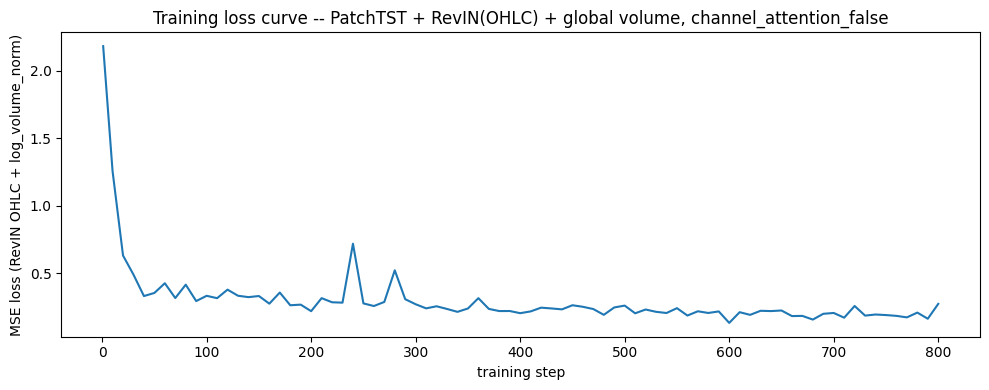

  OHLC MAE / RMSE     : 1.9227 / 3.1203
  volume MAE / RMSE   : 2,186,299.8 / 3,786,949.0
  dir acc per bar     : 0.4777 / 0.4752 / 0.4802
  coherence rate      : 0.8106  (step 2's return-target + no-volume run scored 0/2397 on this exact check)
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume-channel_attention_false.json

training channel_attention_true
epoch  1/20  train_loss=0.843332  val_loss=1.542219
epoch  2/20  train_loss=0.361211  val_loss=0.260046
epoch  3/20  train_loss=0.324719  val_loss=0.312231
epoch  4/20  train_loss=0.318583  val_loss=0.356105
epoch  5/20  train_loss=0.301397  val_loss=0.244477
epoch  6/20  train_loss=0.287024  val_loss=0.266870
epoch  7/20  train_loss=0.282030  val_loss=0.217445
epoch  8/20  train_loss=0.272380  val_loss=0.219954
epoch  9/20  train_loss=0.261621  val_loss=0.208562
epoch 10/20  train_loss=0.256786  val_loss=0.203426
epoch 11/20  train_loss=0.245459  val_loss=0.186687
epoch 12/20  train_loss=0.238310  val_loss=0.1891

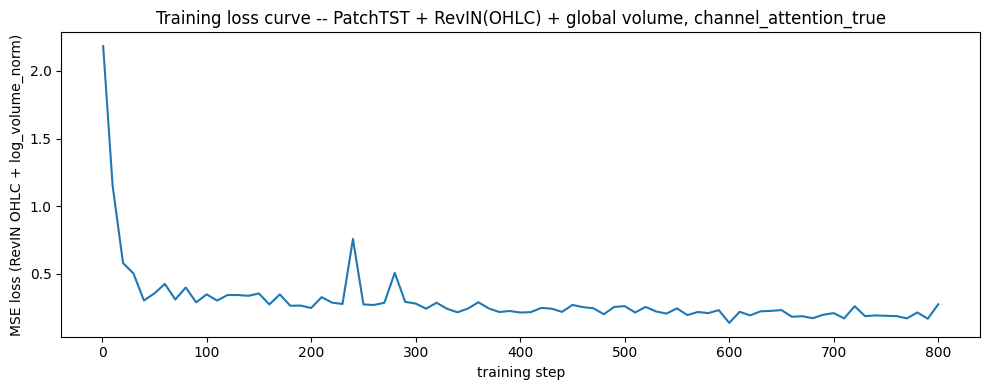

  OHLC MAE / RMSE     : 1.9863 / 3.2385
  volume MAE / RMSE   : 2,217,819.8 / 3,768,344.0
  dir acc per bar     : 0.4752 / 0.4768 / 0.4639
  coherence rate      : 0.8085  (step 2's return-target + no-volume run scored 0/2397 on this exact check)
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume-channel_attention_true.json


In [8]:
def run_epoch(model, loader, optimizer, device, train: bool, loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, n = 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        future_values = batch['future_values'].to(device)

        with torch.set_grad_enabled(train):
            pred_norm = model(past_values)
            # RevIN.fit() was just called inside model() using this batch's context, so
            # model.revin.normalize() here uses the matching context-derived stats to put
            # the true OHLC target in the same normalized space the loss is computed in.
            # Volume's target is already log_volume_norm -- concatenated through unchanged.
            future_price_raw = future_values[:, :, :N_PRICE_CHANNELS]
            future_vol_norm = future_values[:, :, N_PRICE_CHANNELS:]
            true_norm = torch.cat([model.revin.normalize(future_price_raw), future_vol_norm], dim=-1)
            loss = F.mse_loss(pred_norm, true_norm)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = past_values.shape[0]
        total += loss.item() * bs
        n += bs
    return {'loss': total / n}


def mae_rmse(pred: np.ndarray, true: np.ndarray) -> tuple[float, float]:
    diff = pred - true
    return float(np.mean(np.abs(diff))), float(np.sqrt(np.mean(diff ** 2)))


def evaluate(model) -> dict:
    model.eval()
    all_true, all_pred, all_close0 = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            pv = batch['past_values'].to(DEVICE)
            fv = batch['future_values'].to(DEVICE)
            pred_norm = model(pv)
            pred_price = model.revin.denormalize(pred_norm[:, :, :N_PRICE_CHANNELS])
            pred_vol_norm = pred_norm[:, :, N_PRICE_CHANNELS:]
            pred_mixed = torch.cat([pred_price, pred_vol_norm], dim=-1)   # OHLC real, volume still log_volume_norm
            all_true.append(fv.cpu().numpy())
            all_pred.append(pred_mixed.cpu().numpy())
            all_close0.append(pv[:, -1, CLOSE_IDX].cpu().numpy())   # last context bar's real close

    true_raw = np.concatenate(all_true)     # (n, 3, 5) real OHLC + log_volume_norm
    pred_raw = np.concatenate(all_pred)     # (n, 3, 5) real OHLC (denormalized) + log_volume_norm
    close_0 = np.concatenate(all_close0)    # (n,)
    n = len(true_raw)

    true_ohlc = true_raw[:, :, :N_PRICE_CHANNELS]
    pred_ohlc = pred_raw[:, :, :N_PRICE_CHANNELS]
    ohlc_mae, ohlc_rmse = mae_rmse(pred_ohlc, true_ohlc)

    # reconstruct_volume expects log_volume_norm -> real volume, same function/stats every
    # other notebook in this project uses -- no hand-rolled inverse needed here.
    true_vol = reconstruct_volume(true_raw[:, :, N_PRICE_CHANNELS], stats)
    pred_vol = reconstruct_volume(pred_raw[:, :, N_PRICE_CHANNELS], stats)
    vol_mae, vol_rmse = mae_rmse(pred_vol, true_vol)

    true_close_sign = np.sign(true_raw[:, :, CLOSE_IDX] - close_0[:, None])
    pred_close_sign = np.sign(pred_raw[:, :, CLOSE_IDX] - close_0[:, None])
    dir_acc = (true_close_sign == pred_close_sign).mean(axis=0)

    # Coherence check -- the diagnostic this run is testing (see markdown above).
    coherent_up = (pred_close_sign > 0).all(axis=1)
    coherent_down = (pred_close_sign < 0).all(axis=1)
    coherence_rate = float((coherent_up | coherent_down).mean())

    return {
        'n_windows': n,
        'ohlc_mae': ohlc_mae,
        'ohlc_rmse': ohlc_rmse,
        'volume_mae': vol_mae,
        'volume_rmse': vol_rmse,
        'directional_accuracy': dir_acc.tolist(),
        'coherence_rate': coherence_rate,
    }


os.makedirs('steven/comparison_metrics', exist_ok=True)
results = {}

for channel_attention in CHANNEL_ATTENTION_SETTINGS:
    setting_key = f'channel_attention_{str(channel_attention).lower()}'
    print(f'\n{"="*70}\ntraining {setting_key}\n{"="*70}')

    # Reset the seed per setting so both runs get identical weight init/dropout draws --
    # data order is already independent of global RNG state (np.random.default_rng(SEED+epoch)
    # below), but model init/dropout use torch's global RNG, which would otherwise have
    # already been advanced by whichever setting trained first.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = build_model(channel_attention).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    loss_history = []
    step_holder = [0]
    best_val_loss = float('inf')

    for epoch in range(MAX_EPOCHS):
        train_rng = np.random.default_rng(SEED + epoch)
        n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
        train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
        train_ds = FixedContextRawDataset(raw, train_starts)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

        train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, train=True,
                                   loss_history=loss_history, step_holder=step_holder)
        val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

        print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
              f'train_loss={train_metrics["loss"]:.6f}  val_loss={val_metrics["loss"]:.6f}')

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']

    print(f'done ({setting_key}). best val_loss={best_val_loss:.6f}')

    fig, ax = plt.subplots(figsize=(10, 4))
    steps, losses = zip(*loss_history)
    ax.plot(steps, losses)
    ax.set_xlabel('training step')
    ax.set_ylabel('MSE loss (RevIN OHLC + log_volume_norm)')
    ax.set_title(f'Training loss curve -- PatchTST + RevIN(OHLC) + global volume, {setting_key}')
    plt.tight_layout()
    plt.show()

    eval_metrics = evaluate(model)
    print(f'  OHLC MAE / RMSE     : {eval_metrics["ohlc_mae"]:.4f} / {eval_metrics["ohlc_rmse"]:.4f}')
    print(f'  volume MAE / RMSE   : {eval_metrics["volume_mae"]:,.1f} / {eval_metrics["volume_rmse"]:,.1f}')
    dir_acc = eval_metrics['directional_accuracy']
    print(f'  dir acc per bar     : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')
    print(f'  coherence rate      : {eval_metrics["coherence_rate"]:.4f}  '
          f'(step 2\'s return-target + no-volume run scored 0/2397 on this exact check)')

    output = {
        'experiment': {**EXPERIMENT, 'channel_attention': channel_attention, 'seed': SEED},
        'best_val_loss': best_val_loss,
        **eval_metrics,
    }
    results[setting_key] = output

    out_path = f'steven/comparison_metrics/{EXPERIMENT["name"]}-{setting_key}.json'
    with open(out_path, 'w') as f:
        json.dump(output, f, indent=2)
    print(f'  wrote {out_path}')


## Results summary

In [9]:
print(f'{"setting":<26} {"OHLC RMSE":>10} {"Vol RMSE":>14} {"dir acc (bar1/2/3)":>22} {"coherence":>10}')
for setting_key, r in results.items():
    da = r['directional_accuracy']
    print(f'{setting_key:<26} {r["ohlc_rmse"]:>10.4f} {r["volume_rmse"]:>14,.1f} '
          f'{da[0]:>6.4f}/{da[1]:.4f}/{da[2]:.4f}  {r["coherence_rate"]:>9.4f}')


setting                     OHLC RMSE       Vol RMSE     dir acc (bar1/2/3)  coherence
channel_attention_false        3.1203    3,786,949.0 0.4777/0.4752/0.4802     0.8106
channel_attention_true         3.2385    3,768,344.0 0.4752/0.4768/0.4639     0.8085


## Caveats and recommended next steps

- **Coherence rate is the first thing to check**, before OHLC RMSE -- see intro markdown.
  A low coherence rate here (near step 2's 0/2397) would mean adding volume back broke
  RevIN's earlier fix; a high one (near the original volume-free RevIN run's 95-98%) would
  confirm the fix holds regardless of volume.
- **Volume is normalized differently from OHLC on purpose** (global `log_volume_norm`, not
  RevIN) -- see intro markdown. If this run's volume RMSE looks unexpectedly worse than
  steps 1-2's, that's the first thing to check (global scale doesn't adapt to local regime
  the way RevIN's OHLC treatment does), not necessarily a sign the overall framing failed.
- **One seed per setting.** `CHANNEL_ATTENTION_SETTINGS` controls which settings get
  trained in this pass -- both by default.
- **No output bounding at all** (see intro markdown) -- unlike the return-based variants'
  `MAX_LOG_RETURN` cap, nothing currently stops a wild denormalized prediction if training
  is unstable or undertrained. Worth a sanity clip if this approach looks promising enough
  to develop further.
- **RevIN's own limitation (for the OHLC channels)**: it normalizes using each window's own
  trailing mean/std, which assumes the near-term future shares the recent local
  distribution -- reasonable for hourly SPY over 3 bars, but an assumption, not a guarantee.
- **Fixed context (70 bars) vs. steven's variable-length curriculum**, same simplification
  as every other notebook in this family.
- **No backtest yet** -- deferred until a target/volume variant is picked from the ladder.
- **`evaluate.py` does NOT support this checkpoint shape** (no `channel_attention`-only
  arch branch for RevIN, no checkpoint saved this round either) -- this notebook computes
  its own metrics inline instead, same as steps 1-2.
- **Reusing this notebook for step 4** (raw-price target, no volume -- effectively a rerun
  of the original volume-free RevIN result for a clean before/after on volume alone):
  update `EXPERIMENT["name"]`/`["description"]`/`["include_volume"]`, drop the volume
  concatenation in the data/model/loss cells, and set `N_CHANNELS = N_PRICE_CHANNELS` --
  don't fork a new notebook file.


## Commit + push results

Same pattern as `steven/colab_train.ipynb`'s own commit/push cells -- reused here so every
experiment notebook that runs on a fresh Colab VM handles git auth the same way.


In [10]:
# Fresh Colab VM has no git identity configured -- needed for `commit` to work at all.
# Only sets it for this local clone (no --global), harmless to commit/share.
!git -C {REPO_DIR} config user.email "woodychang891121@gmail.com"
!git -C {REPO_DIR} config user.name "WoodyChang21"

commit_msg = f"chore(model): log {EXPERIMENT['name']} comparison_metrics from this Colab run"

!git add steven/comparison_metrics
!git status
!git commit -m {commit_msg!r}


On branch patchtst_ohlcv_mse
Your branch is up to date with 'origin/patchtst_ohlcv_mse'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume-channel_attention_true.json

[patchtst_ohlcv_mse 1245736] chore(model): log hf_patchtst_revin_ohlc_global_volume comparison_metrics from this Colab run
 2 files changed, 50 insertions(+)
 create mode 100644 steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume-channel_attention_false.json
 create mode 100644 steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume-channel_attention_true.json


In [11]:
import getpass

# Fresh Colab VM has no stored GitHub credentials, so a plain `git push` over HTTPS
# can't authenticate. Prompting interactively (getpass masks it, and it's never written
# into this notebook's saved source/outputs) instead of hardcoding a token in a cell --
# a hardcoded token would get committed into git history the moment this notebook is
# pushed, which is a real credential leak. Needs a GitHub Personal Access Token with
# `repo` scope: https://github.com/settings/tokens
token = getpass.getpass("GitHub Personal Access Token: ")
push_url = f"https://{token}@github.com/WoodyChang21/ECE1508_GenAI.git"
!git -C {REPO_DIR} push {push_url} {BRANCH}
del token, push_url  # don't leave it sitting in a notebook-visible variable longer than needed


Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 12 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 1.27 KiB | 1.27 MiB/s, done.
Total 6 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 3 local objects.
To https://github.com/WoodyChang21/ECE1508_GenAI.git
   20a659d..1245736  patchtst_ohlcv_mse -> patchtst_ohlcv_mse
